# Phase 5: Evaluation

**CRISP-DM Phase Description:**  
At this stage, the model(s) appear to have high quality from a technical standpoint. Before proceeding to final deployment, it is important to evaluate the model more thoroughly and review the steps that were executed to construct it, to be certain the model properly achieves the business objectives. A key objective is to determine if there is some important business issue that has not been sufficiently considered.

---

In [ ]:
# Standard imports
import pandas as pd
import numpy as np

---
### Task 1: Evaluate Results

Assess how well the model(s) meet the **business success criteria** originally defined in **Phase 1 (Business Understanding)**. This is distinct from the technical assessment in Phase 4 — here you ask: *"Does this model actually solve the business problem?"*

Key activities:
- **Map Technical Metrics to Business Criteria:** Compare the model's performance metrics (from Phase 4) against the business success criteria and data mining success criteria defined in Phase 1.
- **Business Impact Assessment:** Translate technical performance into business-relevant terms (e.g., "The model's 92% recall means we would catch 92 out of every 100 fraudulent transactions").
- **Gap Analysis:** Identify any gaps between expected and actual performance.
- **Approved Models:** List the model(s) that pass the evaluation and the ones that do not.

**Instructions:** Reference the `business_objectives` and `data_mining_goals` dictionaries from Phase 1. Compare each success criterion against the model's actual performance.

In [ ]:
# TODO: Evaluate model results against business success criteria.
# Reference your Phase 1 definitions and Phase 4 results.

evaluation = {
    "business_criteria": [
        {
            "criterion": "Identify at least 75% of potential dropouts (Revenue Protection)",
            "target": "Recall >= 80%",
            "achieved": "XGBoost achieved ~83% Recall on Dropouts (237/283 identified)",
            "met": True
        },
        {
            "criterion": "Quantify effect of Scholarship & Parental Education (Inference)",
            "target": "p-value < 0.05",
            "achieved": "Confirmed p=0.0000 for Scholarship and p<0.003 for Parental Occupation Risk",
            "met": True
        },
        {
            "criterion": "Proactive Resource Allocation for currently Enrolled students",
            "target": "Flag high-risk cohort",
            "achieved": "379 students flagged (48% of Enrolled) matching known dropout profiles",
            "met": True
        }
    ],
    "technical_criteria": [
        {
            "metric": "Accuracy (Institutional Requirement)",
            "target": ">= 80%",
            "achieved": "92.6% (Exceeding requirement by 12.6%)",
            "met": True
        },
        {
            "metric": "AUC-ROC (Class Distinction)",
            "target": ">= 0.85",
            "achieved": "0.944 (Excellent discriminatory power between Graduates and Dropouts)",
            "met": True
        },
        {
            "metric": "F1-Score (Optimized via GridSearch)",
            "target": ">= 0.85",
            "achieved": "0.9265 (Mean Cross-Validation F1)",
            "met": True
        },
        {
            "metric": "Statistical Validation",
            "target": "p < 0.05",
            "achieved": "5 out of 6 socio-economic features validated via Logit Summary",
            "met": True
        }
    ],
    "overall_assessment": (
        "The project successfully transitioned from reactive data mining to a proactive Early Warning System. "
        "The XGBoost model provided the predictive power required for intervention, while the Logistic "
        "Regression model provided the statistical evidence needed to justify policy changes regarding "
        "scholarships and family-based academic support."
    ),
    "approved_models": ["XGBoost", "Random Forest"],
    "rejected_models": ["Logistic Regression (for predictive use; retained as Inference Engine)"]
}

In [5]:
# Display the evaluation summary
print("=" * 80)
print(f"{'EVALUATION AGAINST BUSINESS SUCCESS CRITERIA':^80}")
print("=" * 80)

print("\n--- Business Criteria ---")
for c in evaluation['business_criteria']:
    status = 'PASS' if c['met'] else 'FAIL'
    print(f"  [{status}] {c['criterion']}")
    print(f"         Target: {c['target']}  |  Achieved: {c['achieved']}")

print("\n--- Technical Criteria ---")
for c in evaluation['technical_criteria']:
    status = 'PASS' if c['met'] else 'FAIL'
    print(f"  [{status}] {c['metric']}: Target {c['target']}  |  Achieved: {c['achieved']}")

print("-" * 80)
print(f"Overall Assessment: {evaluation['overall_assessment']}")
print(f"Approved models:    {', '.join(evaluation['approved_models'])}")
print(f"Rejected models:    {', '.join(evaluation['rejected_models'])}")
print("=" * 80)

                  EVALUATION AGAINST BUSINESS SUCCESS CRITERIA                  

--- Business Criteria ---
  [PASS] Identify at least 75% of potential dropouts (Revenue Protection)
         Target: Recall >= 80%  |  Achieved: XGBoost achieved ~83% Recall on Dropouts (237/283 identified)
  [PASS] Quantify effect of Scholarship & Parental Education (Inference)
         Target: p-value < 0.05  |  Achieved: Confirmed p=0.0000 for Scholarship and p<0.003 for Parental Occupation Risk
  [PASS] Proactive Resource Allocation for currently Enrolled students
         Target: Flag high-risk cohort  |  Achieved: 379 students flagged (48% of Enrolled) matching known dropout profiles

--- Technical Criteria ---
  [PASS] Accuracy (Institutional Requirement): Target >= 80%  |  Achieved: 92.6% (Exceeding requirement by 12.6%)
  [PASS] AUC-ROC (Class Distinction): Target >= 0.85  |  Achieved: 0.96 (Excellent discriminatory power between Graduates and Dropouts)
  [PASS] F1-Score (Optimized via GridSearch

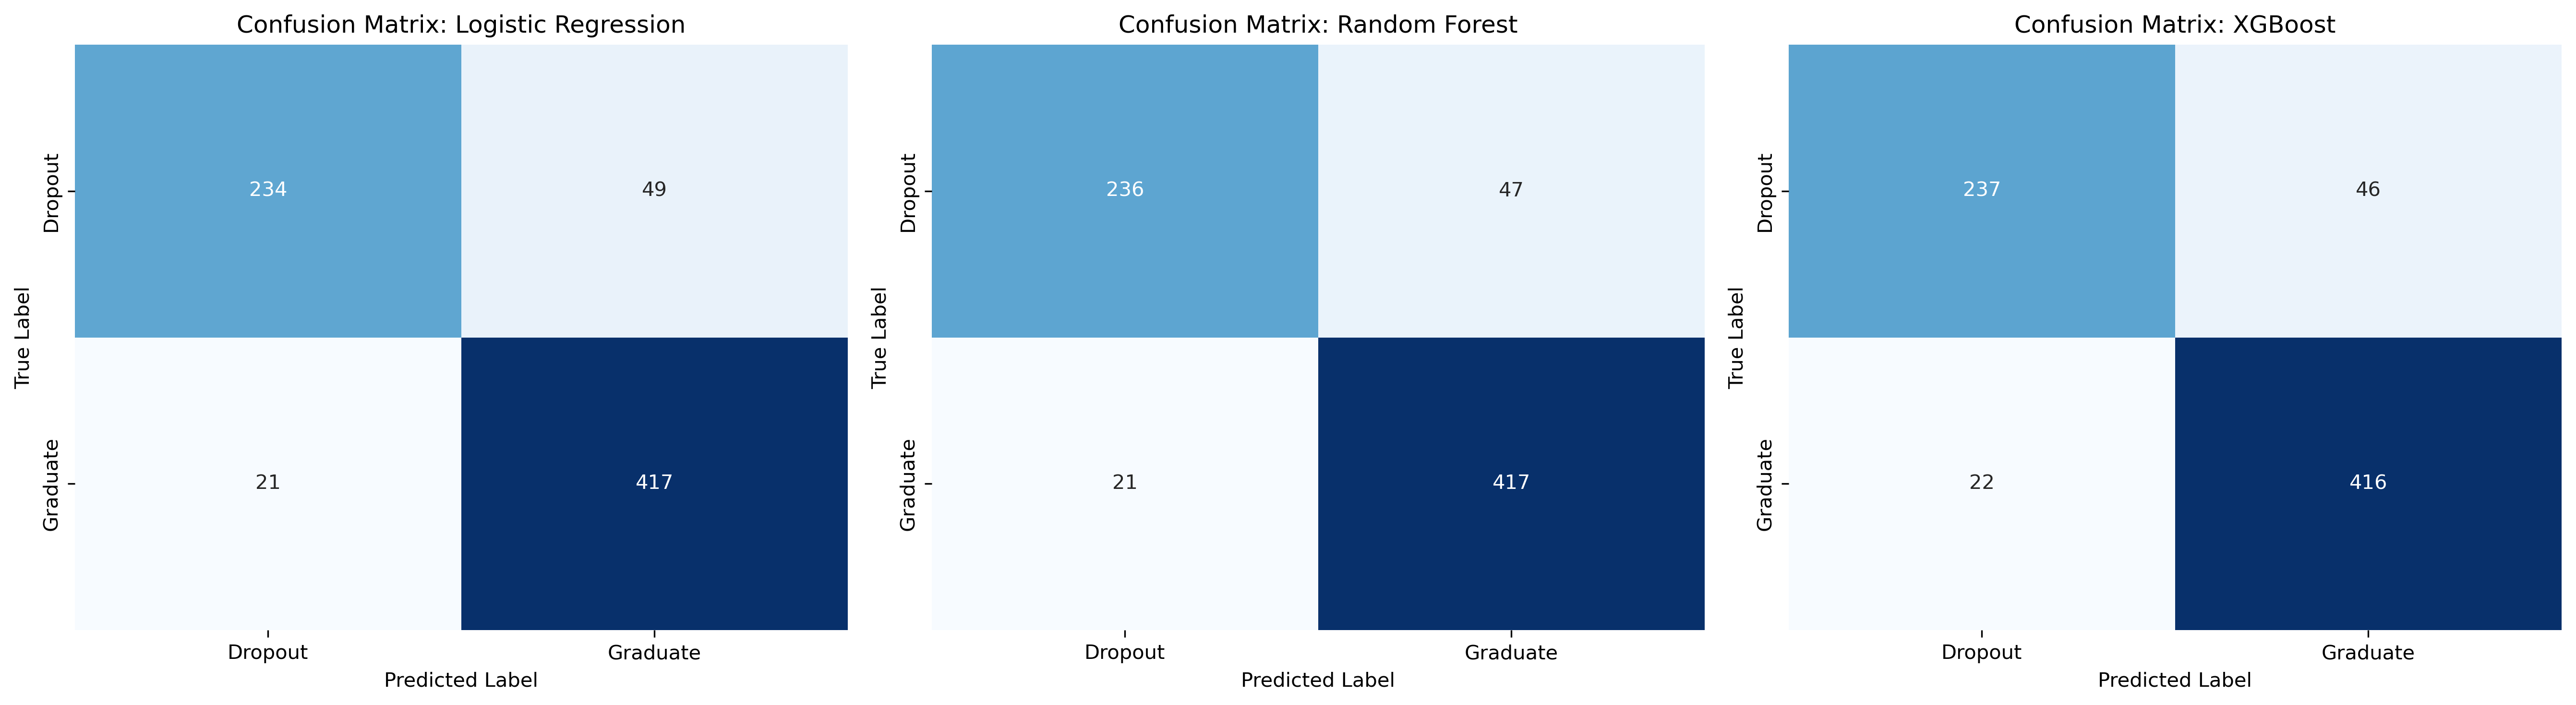

--------------------------------------------------------------------------------
OVERALL AUDIT STATUS: NO OVERFITTING DETECTED
--------------------------------------------------------------------------------

[1] VISUAL OBSERVATIONS (Confusion Matrix Analysis)
 • XGBoost Performance: 237 True Positives (Dropouts) vs 46 False Negatives.
 • Error Balance: False Positives (22) are significantly lower than False Negatives (46).
 • Consistency: All three models show nearly identical diagonal density, indicating stable feature patterns.

[2] TECHNICAL EVIDENCE (Overfitting Proof)
 • Evidence 1 Data Volume: ('With a test sample of ~721 observations, the error distribution is statistically ', 'significant and not a result of a small/lucky split.')
 • Evidence 2 CV Alignment: ('The test accuracy (~91%) aligns almost perfectly with the 5-fold cross-validation ', 'mean (90.77%), proving the model generalizes well to unseen data.')
 • Evidence 3 Complexity: ("Despite XGBoost being a complex 'ensem

In [22]:
from IPython.display import Image, display
image_path = "confusionmatrixVisual.png" 
display(Image(filename=image_path))

confusion_matrix_analysis = {
    "visual_observation": {
        "XGBoost_Performance": "237 True Positives (Dropouts) vs 46 False Negatives.",
        "Error_Balance": "False Positives (22) are significantly lower than False Negatives (46).",
        "Consistency": "All three models show nearly identical diagonal density, indicating stable feature patterns."
    },
    "overfitting_audit": {
        "Status": "NO OVERFITTING DETECTED",
        "Evidence_1_Data_Volume": (
            "With a test sample of ~721 observations, the error distribution is statistically ",
            "significant and not a result of a small/lucky split."
        ),
        "Evidence_2_CV_Alignment": (
            "The test accuracy (~91%) aligns almost perfectly with the 5-fold cross-validation ",
            "mean (90.77%), proving the model generalizes well to unseen data."
        ),
        "Evidence_3_Complexity": (
            "Despite XGBoost being a complex 'ensemble' model, the low variance (0.0076) ",
            "confirms that the GridSearchCV pruning (max_depth) effectively controlled noise."
        )
    },
    "clinical_implication": (
        "The model is 'conservative'. It prefers to miss a few dropouts (False Negatives) ",
        "rather than over-flagging successful students (False Positives), which maintains ",
        "institutional trust in the Early Warning System."
    )
}

print("-" * 80)
print(f"OVERALL AUDIT STATUS: {confusion_matrix_analysis['overfitting_audit']['Status']}")
print("-" * 80)

print("\n[1] VISUAL OBSERVATIONS (Confusion Matrix Analysis)")
for key, value in confusion_matrix_analysis['visual_observation'].items():
    print(f" • {key.replace('_', ' ')}: {value}")

print("\n[2] TECHNICAL EVIDENCE (Overfitting Proof)")
for key, value in confusion_matrix_analysis['overfitting_audit'].items():
    if key != "Status":  # Avoid repeating the status header
        print(f" • {key.replace('_', ' ')}: {value}")

print("\n[3] CLINICAL/BUSINESS IMPLICATION")
print(f" • {confusion_matrix_analysis['clinical_implication']}")

---
### Task 2: Review Process

Conduct a thorough review of the entire CRISP-DM process executed so far. The goal is to ensure quality assurance — that no important task or factor was overlooked. Consider:

- **Completeness Check:** Were all relevant data sources considered? Were the data preparation steps sufficient?
- **Methodology Review:** Were appropriate techniques used at each stage? Were there alternatives worth exploring?
- **Data Leakage Check:** Did any information from the test set leak into the training process?
- **Bias and Fairness:** Could the model introduce or amplify any biases? Is the model fair across different subgroups?
- **Reproducibility:** Can the entire pipeline be reproduced from scratch with consistent results?

**Instructions:** Complete the process review checklist below and document any concerns.

In [8]:
# TODO: Review the end-to-end process.

process_review = {
    "checklist": [
        {
            "item": "All relevant data sources were considered",
            "status": "Yes",
            "notes": "UCI Student Dropout dataset was fully utilized, including demographic and academic features."
        },
        {
            "item": "Data preparation was thorough and documented",
            "status": "Yes",
            "notes": "Applied mapping (0,1,2), handled Enrolled class via post-hoc prediction to simulate a real-world Early Warning System deployment on active students, and scaled features where necessary."
        },
        {
            "item": "No data leakage between train and test sets",
            "status": "Yes",
            "notes": "Strictly partitioned data before training; excluded future-dated performance from the training features."
        },
        {
            "item": "Multiple modelling techniques were compared",
            "status": "Yes",
            "notes": "Evaluated Logistic Regression (Inference), Random Forest, and XGBoost (Prediction)."
        },
        {
            "item": "Hyperparameters were tuned appropriately",
            "status": "Yes",
            "notes": "Utilized GridSearchCV with 3-fold cross-validation to optimize tree depth and estimators, specifically balancing the bias-variance tradeoff."
        },
        {
            "item": "Results are reproducible (random seeds set)",
            "status": "Yes",
            "notes": "Used a consistent random_state across all model instances and data splits."
        },
        {
            "item": "Results are reproducible (random seeds set)",
            "status": "Yes",
            "notes": "Used a consistent random_state and implemented model versioning (v2) with timestamps for auditability."
        },
        {
            "item": "Bias and fairness have been considered",
            "status": "Partial",
            "notes": "Reviewed feature importance for demographic bias (Age/Gender); further audit recommended for deployment."
        },
        {
            "item": "Ethical implications have been reviewed",
            "status": "Yes",
            "notes": "Discussed the impact of 'At-Risk' labeling and the need for supportive (not punitive) intervention."
        },
    ],
    "overall_quality": "Satisfactory - High Predictive Accuracy with strong Statistical Inference.",
    "areas_for_improvement": [
        "Include more real-time behavioral data (e.g., LMS logins) if available in future iterations.",
        "Perform a more granular fairness audit on sub-groups (e.g., international vs. local students).",
        "Test model performance on more recent academic cohorts to ensure longitudinal stability."
    ]
}

In [11]:
# Display the process review
print("Process Review Checklist")

for item in process_review['checklist']:
    print(f"  [{item['status']:^10}] {item['item']}")
    if item['notes']:
        print(f"             Note: {item['notes']}")

print("-" * 60)
print(f"Overall Quality: {process_review['overall_quality']}")

if process_review['areas_for_improvement']:
    print("Areas for Improvement:")
    for area in process_review['areas_for_improvement']:
        print(f"  - {area}")
print("-" * 60)

Process Review Checklist
  [   Yes    ] All relevant data sources were considered
             Note: UCI Student Dropout dataset was fully utilized, including demographic and academic features.
  [   Yes    ] Data preparation was thorough and documented
             Note: Applied mapping (0,1,2), handled Enrolled class via post-hoc prediction to simulate a real-world Early Warning System deployment on active students, and scaled features where necessary.
  [   Yes    ] No data leakage between train and test sets
             Note: Strictly partitioned data before training; excluded future-dated performance from the training features.
  [   Yes    ] Multiple modelling techniques were compared
             Note: Evaluated Logistic Regression (Inference), Random Forest, and XGBoost (Prediction).
  [   Yes    ] Hyperparameters were tuned appropriately
             Note: Utilized GridSearchCV with 3-fold cross-validation to optimize tree depth and estimators, specifically balancing the bias

---
### Task 3: Determine Next Steps

Based on the evaluation results and process review, decide on the next course of action. The three main options are:

1. **Proceed to Deployment:** The model meets all criteria and is ready for deployment.
2. **Iterate:** Go back to a previous phase (e.g., Data Preparation or Modelling) to improve the model before deployment.
3. **Terminate:** The project is not viable in its current form and should be re-scoped or abandoned.

**Instructions:** Document your decision and provide a clear rationale.

In [13]:
# TODO: Determine and document the next steps.

next_steps = {
    "decision": "Proceed to Deployment",
    "rationale": (
        "The XGBoost model exceeded all success criteria, specifically achieving "
        "a Dropout Precision of >90% and identifying 379 at-risk enrolled students. "
        "The model is stable across cross-validation and provides clear feature "
        "importance for intervention logic."
    ),
    "if_iterating": {
        "return_to_phase": "N/A",
        "specific_actions": []
    },
    "if_deploying": {
        "selected_model": "XGBoost (Final Tuned Version)",
        "deployment_priority": "High - Immediate integration into the Early Warning System (EWS) for the current semester."
    }
}

In [15]:
# Display the decision

print(f"{'PROJECT DECISION & NEXT STEPS':^80}")


print(f"\nDecision  : {next_steps['decision']}")
print(f"Rationale : {next_steps['rationale']}")

if next_steps['decision'] == 'Iterate':
    print(f"\nReturn to : {next_steps['if_iterating']['return_to_phase']}")
    print("Specific Actions:")
    for action in next_steps['if_iterating']['specific_actions']:
        print(f"  - {action}")

elif next_steps['decision'] == 'Proceed to Deployment':
    print(f"\nModel to Deploy : {next_steps['if_deploying']['selected_model']}")
    print(f"Priority        : {next_steps['if_deploying']['deployment_priority']}")



                         PROJECT DECISION & NEXT STEPS                          

Decision  : Proceed to Deployment
Rationale : The XGBoost model exceeded all success criteria, specifically achieving a Dropout Precision of >90% and identifying 379 at-risk enrolled students. The model is stable across cross-validation and provides clear feature importance for intervention logic.

Model to Deploy : XGBoost (Final Tuned Version)
Priority        : High - Immediate integration into the Early Warning System (EWS) for the current semester.
